In [3]:
# Ô CODE 2: KHỞI TẠO SPARK VÀ THỰC HIỆN TRUY VẤN
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

print("[1] Khởi tạo hệ thống Spark và nạp gói driver AWS S3A...")
spark = SparkSession.builder \
    .appName("MinIO_Log_Analysis_InDepth") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .getOrCreate()

print("[2] Kết nối và tải dữ liệu từ MinIO...")
s3_path = "s3a://logs/web_logs_large.csv"
df_logs = spark.read.csv(s3_path, header=True, inferSchema=True)

# ----------------- THỰC HIỆN CÁC YÊU CẦU BÀI TẬP -----------------
print("\n" + "="*50 + "\n BÁO CÁO KẾT QUẢ PHÂN TÍCH SƠ BỘ\n" + "="*50)

# Yêu cầu 6a: Đếm tổng số bản ghi
total_records = df_logs.count()
print(f"👉 Tổng số bản ghi log ghi nhận được: {total_records:,} dòng\n")

# Yêu cầu 6b: Đếm số lượt truy cập theo page
print("👉 Thống kê lượng tương tác theo từng Page:")
df_logs.groupBy("page").count().orderBy(F.desc("count")).show()

# Yêu cầu 6c: Tìm 5 trang có số lượt truy cập cao nhất
print("👉 Top 5 trang hot nhất hệ thống:")
df_logs.groupBy("page").count().orderBy(F.desc("count")).limit(5).show()

# Yêu cầu 6d: Đếm số lượt theo device
print("👉 Cơ cấu thiết bị người dùng sử dụng:")
df_logs.groupBy("device").count().orderBy(F.desc("count")).show()

# Yêu cầu 6e: Đếm số lượt theo country
print("👉 Phân phối lưu lượng truy cập theo Quốc gia:")
df_logs.groupBy("country").count().orderBy(F.desc("count")).show()

# Yêu cầu 7 & 8: Tạo cột date từ timestamp và tính số lượt theo ngày
df_logs = df_logs.withColumn("date", F.to_date(F.col("timestamp")))
daily_traffic_pd = df_logs.groupBy("date").count().orderBy("date").toPandas()


# ----------------- PHẦN BỔ SUNG: PHÂN TÍCH CHUYÊN SÂU -----------------
print("\n" + "="*50 + "\n PHẦN MỞ RỘNG: BỔ SUNG CHỈ SỐ DOANH NGHIỆP\n" + "="*50)

# Tính Chỉ số DAU (Daily Active Users) - Số người dùng duy nhất tương tác mỗi ngày
print("👉 Thống kê chỉ số người dùng duy nhất hoạt động mỗi ngày (DAU) - 10 ngày đầu:")
dau_df = df_logs.groupBy("date").agg(F.countDistinct("user_id").alias("DAU")).orderBy("date")
dau_df.show(10)

# Tính tỷ lệ chuyển đổi thẳng đến trang thanh toán (Conversion Rate to Payment)
payment_clicks = df_logs.filter(F.col("page") == "payment").count()
conversion_rate = (payment_clicks / total_records) * 100
print(f"👉 Tỷ lệ người dùng đi đến bước cuối cùng (Payment Conversion Rate): {conversion_rate:.2f}%")

[1] Khởi tạo hệ thống Spark và nạp gói driver AWS S3A...
[2] Kết nối và tải dữ liệu từ MinIO...

 BÁO CÁO KẾT QUẢ PHÂN TÍCH SƠ BỘ
👉 Tổng số bản ghi log ghi nhận được: 1,000,000 dòng

👉 Thống kê lượng tương tác theo từng Page:
+--------------+------+
|          page| count|
+--------------+------+
|          home|398594|
|  product_list|250585|
|product_detail|200506|
|          cart| 80161|
|      checkout| 50279|
|       payment| 19875|
+--------------+------+

👉 Top 5 trang hot nhất hệ thống:
+--------------+------+
|          page| count|
+--------------+------+
|          home|398594|
|  product_list|250585|
|product_detail|200506|
|          cart| 80161|
|      checkout| 50279|
+--------------+------+

👉 Cơ cấu thiết bị người dùng sử dụng:
+-------+------+
| device| count|
+-------+------+
| mobile|700298|
|desktop|249643|
| tablet| 50059|
+-------+------+

👉 Phân phối lưu lượng truy cập theo Quốc gia:
+---------+------+
|  country| count|
+---------+------+
|  Vietnam|600548|
|  

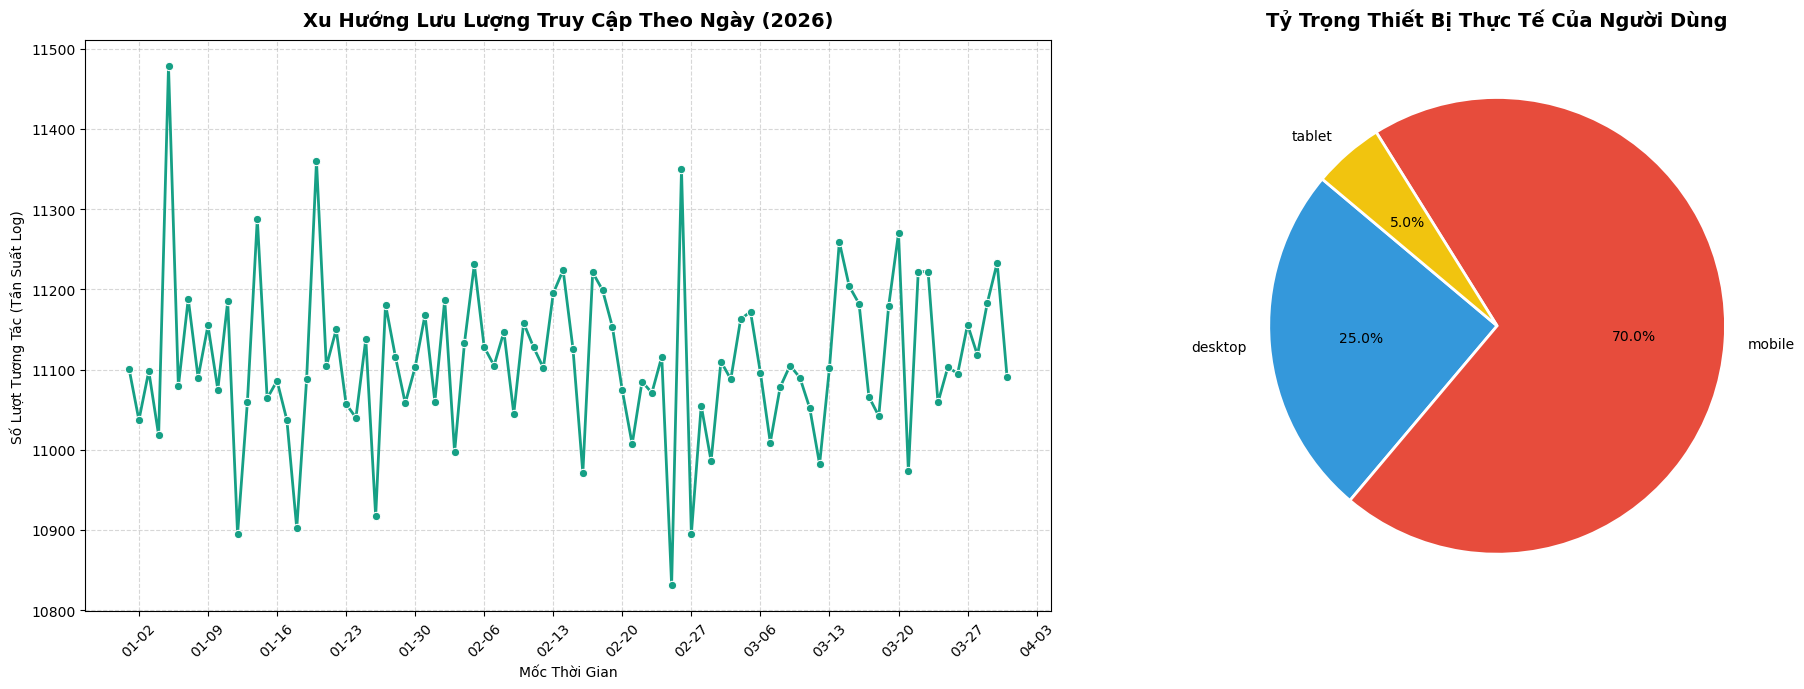

In [4]:
# Ô CODE 3: VẼ BIỂU ĐỒ BÁO CÁO
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Lấy thêm dữ liệu thiết bị về dạng pandas để vẽ pie chart
device_pd = df_logs.groupBy("device").count().toPandas()

# Khởi tạo khung chứa 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Biểu đồ 1: Line Chart - Xu hướng truy cập theo ngày (Yêu cầu 9)
sns.lineplot(ax=axes[0], data=daily_traffic_pd, x='date', y='count', 
             marker='o', color='#16a085', linewidth=2, markersize=6)
axes[0].set_title('Xu Hướng Lưu Lượng Truy Cập Theo Ngày (2026)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Mốc Thời Gian')
axes[0].set_ylabel('Số Lượt Tương Tác (Tần Suất Log)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=7))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Biểu đồ 2: Pie Chart - Tỷ trọng thiết bị truy cập (Bổ sung trực quan)
axes[1].pie(device_pd['count'], labels=device_pd['device'], autopct='%1.1f%%',
        startangle=140, colors=['#3498db', '#e74c3c', '#f1c40f'], 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỷ Trọng Thiết Bị Thực Tế Của Người Dùng', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()